# Parkplätze in Wien

## Daten aufbereiten

### Parkflächen ermitteln
Quelle: Flächenmehrzweckkarte (FMZK) der Stadt Wien (https://www.data.gv.at/katalog/dataset/7cf0da04-1f77-4321-929e-78172c74aa0b)  
Stand: 15. Oktober 2024

Die FMZK enthält fehlerhafte Einträge:

```geopandas.read_file("fmzk.gpkg")```

```GEOSException: IllegalArgumentException: point array must contain 0 or >1 elements```

Umweg über QGIS:
* FMZK Geopackage importieren
* Layer filtern nach ```"F_KLASSE_TEXT" = "Ruhender Verkehr"```
* Layer CRS auf *EPSG: 31256* setzen
* Gefilterte Layer ohne Metadaten als Geopackage exportieren

<Axes: >

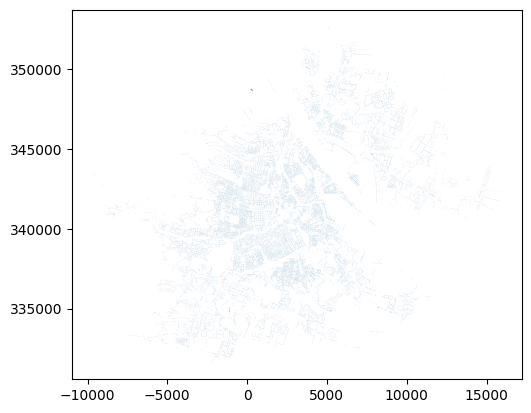

In [33]:
import geopandas as gpd

parkflaechen = gpd.read_file("fmzk_parkflaechen.gpkg")
parkflaechen.plot()

### Parkflächen in einzelne Parkplätze aufteilen

#### Largest interior rectangles finden
Parkflächen sind oft wenig rechtecksähnlich und können Löcher enthalten (z.B. Baumscheiben).  
Für die Aufteilung in einzelne Parkplätze zunächst die Parkflächen-Polygone mit möglichst großen Rechtecken füllen.  
Dafür gibts folgendes Package: https://github.com/OpenStitching/lir

Herausforderungen:
1. **Das LIR-Package findet nur axis-aligned LIRs**  
Parkflächen-Polygone sind beliebig orientiert
2. **Das LIR-Package repräsentiert den Polygon intern als binary grid**  
Parkflächen-Polygone liegen als Gleitkomma EPSG:31256-Koordinaten vor. Skalierung auf Ganzzahlen erfordert zu großes grid.

Lösungen:
1. **Achsenausrichtung**
    1. Minimum-Bounding-Rectangle (MBR) für Parkflächen-Polygon berechnen
    2. Winkel zwischen MBR und x-Achse berechnen
    3. Parkflächen-Polygon um berechneten Winkel rotieren
    4. LIR berechnen und zurückrotieren um Schwerpunkt des Originalpolygons
2. **Koordinaten normalisieren**
    1. EPSG:31256-Koordinaten des Polygon offsetten um Minimalkoordinate des Polygon
    2. Verkleinerte Koordinaten skalieren und runden, Genauigkeit von 10cm (resolution=0.1) ausreichend
    3. LIR berechnen und zurückskalieren bzw. -offsetten auf EPSG:31256-Koordinaten

Gefundenes LIR von Parkflächen-Polygon abschneiden und Algorithmus auf Restpolygon anwenden bis LIR kleiner als 2x6 bzw. 6x2 Meter. 
2 Meter ist eigentlich zu schmal für einen Parkplatz aber im Falle eines gekrümmten Parkflächen-Polygons sind die gefundenen LIRs stets schmäler als die originale Parkfläche.

Die meisten Parkflächen sind eh rechteckig - eine zweite, zeitintensive LIR-Berechnung nur anstarten wenn restliche Fläche groß genug für weiteren Parkplatz (ca. 12qm)

**Auf einem Macbook Air M1 rennt die Berechnung der LIRs für die gut 63.000 Parkflächen-Polygone etwa 30 Minuten.**

<Axes: >

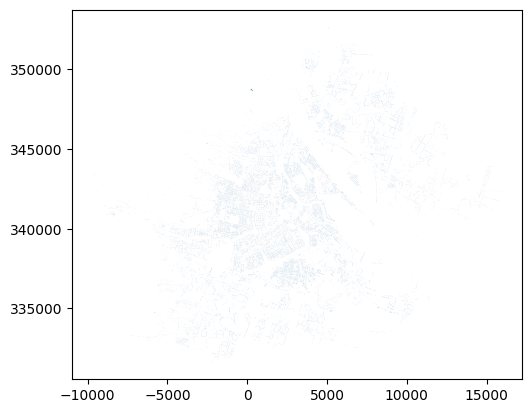

In [34]:
import numpy as np
import math
from shapely.geometry import MultiPolygon, box
from shapely import affinity
import largestinteriorrectangle as lir
from matplotlib import pyplot as plt

def align_to_xaxis(poly):
    # Get the minimum area bounding rectangle (already axis-aligned)
    min_rect = poly.minimum_rotated_rectangle

    # Get the coordinates of the bounding rectangle
    rect_coords = list(min_rect.exterior.coords)

    # Ensure we have at least 4 unique points
    if len(rect_coords) < 5:
        raise ValueError("Bounding rectangle does not have enough points")

    # Extract the first two distinct points to compute orientation
    x1, y1 = rect_coords[0]
    x2, y2 = rect_coords[1]

    # Compute the angle between the first edge and the x-axis
    angle = -math.degrees(math.atan2(y2 - y1, x2 - x1))

    # Rotate the polygon to align with the x-axis
    centroid = poly.centroid.coords[0]  # Store centroid before rotation
    rotated_poly = affinity.rotate(poly, angle, origin=centroid, use_radians=False)

    return rotated_poly, angle, centroid


def normalize(poly, resolution):
    minx, miny, _, _ = poly.bounds  # Get bounding box

    # Get exterior coordinates of the polygon
    coords = np.array(poly.exterior.coords)

    # Offset coordinates by subtracting minx, miny
    coords[:, 0] -= minx  # Adjust X-coordinates
    coords[:, 1] -= miny  # Adjust Y-coordinates

    # Round to the nearest resolution and convert to integer grid
    coords = (coords / resolution).round().astype(np.int32)

    # Reshape to 3D array with shape (1, n, 2)
    coords = coords[np.newaxis, :, :]  # Adds the extra dimension

    return coords, (minx, miny)


def denormalize(rect, offset, resolution):
    x_normalized, y_normalized, width_normalized, height_normalized = rect
    minx, miny = offset

    x = x_normalized * resolution + minx
    y = y_normalized * resolution + miny
    width = width_normalized * resolution
    height = height_normalized * resolution

    # Compute max x and y
    maxx = x + width
    maxy = y + height

    return box(x, y, maxx, maxy)


def compute_all_lirs(parking_lane_polygon, min_dim1=2, min_dim2=5, resolution=0.1):
    # Step 1: Rotate the polygon to be axis aligned.
    rotated_poly, angle, centroid = align_to_xaxis(parking_lane_polygon)
    
    polys_queue = [rotated_poly]  # Work in rotated space
    found_lirs = []
    
    while polys_queue:
        current_poly = polys_queue.pop()

        # Step 2: Normalize the polygon coordinates.
        normalized_poly, offset = normalize(current_poly, resolution)
        
        # Step 3: Run the LIR algorithm on the normalized polygon. (Assuming lir.lir returns [x, y, w, h] in grid cells.)
        lir_normalized_rect = lir.lir(normalized_poly)
        if lir_normalized_rect is None:
            continue  # No LIR found
        
        # Step 4: Convert the normalized rectangle to a polygon in EPSG:31256 coordinates.
        lir_rotated = denormalize(lir_normalized_rect, offset, resolution)
        
        # Step 5: Check if the rectangle meets the minimum size criteria.
        lx, ly, ux, uy = lir_rotated.bounds
        width = ux - lx
        height = uy - ly
        if not ((width >= min_dim1 and height >= min_dim2) or (width >= min_dim2 and height >= min_dim1)):
            continue
        
        # Accept this LIR.
        found_lirs.append(lir_rotated)
        
        # Step 6: Subtract the found LIR from the current polygon.
        new_poly = current_poly.difference(lir_rotated)
        if new_poly.is_empty or new_poly.area < 10:
            continue
        
        if isinstance(new_poly, MultiPolygon):
          polys_queue.extend(list(new_poly.geoms))
        else:
          polys_queue.append(new_poly)
    
    # Step 7: Rotate all found LIRs back to the original coordinate system.
    final_lirs = [affinity.rotate(lir_, -angle, origin=centroid, use_radians=False) for lir_ in found_lirs]
    return final_lirs


parkflaechen_lirs = parkflaechen['geometry'].apply(compute_all_lirs)
parkflaechen_lirs = [lir for sublist in parkflaechen_lirs for lir in sublist]
parkflaechen_lirs = gpd.GeoDataFrame({'geometry': parkflaechen_lirs}, crs=parkflaechen.crs)
parkflaechen_lirs.plot()

#### LIRs in Parkplätze aufteilen

TODO dokumentieren

<Axes: >

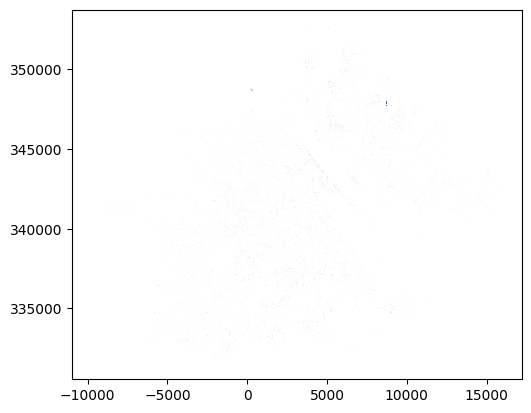

In [11]:
def split_parkflaeche(poly, min_parallel=6, min_perp=3):
    """
    Split a rectangular parking lane polygon into subrectangles (parking spots).
    
    Parameters:
      poly         : shapely Polygon (assumed to be a rectangle with 4 vertices)
      min_parallel : minimum spot length (m) for a parallel parking lane (if lane width < 3 m)
      min_perp     : minimum spot length (m) for a perpendicular parking lane (if lane width >= 3 m)
      
    Returns:
      A list of shapely Polygons corresponding to the individual parking spots.
    """
    # Get the 4 unique vertices (ignore the closing coordinate which equals the first)
    coords = list(poly.exterior.coords)[:-1]
    if len(coords) != 4:
        raise ValueError("Polygon does not have 4 vertices!")
    
    # Helper function to compute Euclidean distance
    def dist(a, b):
        return math.hypot(b[0]-a[0], b[1]-a[1])
    
    # Compute the lengths of the first two edges.
    d0 = dist(coords[0], coords[1])
    d1 = dist(coords[1], coords[2])
    
    # Decide which edge is the “length” (longer side)
    if d0 >= d1:
        # Use the vector from coords[0] to coords[1] for orientation
        dx = coords[1][0] - coords[0][0]
        dy = coords[1][1] - coords[0][1]
    else:
        # Use the vector from coords[1] to coords[2] for orientation
        dx = coords[2][0] - coords[1][0]
        dy = coords[2][1] - coords[1][1]
    
    # Calculate the angle (in degrees) of the long side relative to the x-axis.
    theta = math.degrees(math.atan2(dy, dx))
    
    # Rotate the polygon so that the long side is horizontal.
    # We use the polygon’s centroid as the rotation center.
    cen = poly.centroid
    poly_rot = affinity.rotate(poly, -theta, origin=cen)
    
    # Get the bounds of the rotated polygon.
    minx, miny, maxx, maxy = poly_rot.bounds
    L_aligned = maxx - minx  # This is the (rotated) length
    W_aligned = maxy - miny  # This is the (rotated) width
    
    # Determine the type of parking lane based on the lane’s width:
    # if width < 3 m → parallel parking (min spot length = 5 m)
    # else → perpendicular parking (min spot length = 3.5 m)
    req = min_parallel if W_aligned < 3 else min_perp
    
    # Compute the number of spots that fit (each gets at least req meters)
    n = int(math.floor(L_aligned / req))
    # (Make sure we have at least one spot.)
    n = max(n, 1)
    
    # Now, each spot will actually be L_aligned/n long so that any extra length is equally shared.
    spot_len = L_aligned / n
    
    spots = []
    # For each spot, build a subrectangle in the rotated coordinate system.
    for i in range(n):
        # The lower-left corner of the i-th spot:
        ll = (minx + i * spot_len, miny)
        ur = (minx + (i + 1) * spot_len, maxy)
        subrect = box(*ll, *ur)
        # Rotate the subrectangle back to the original coordinate system.
        subrect_orig = affinity.rotate(subrect, theta, origin=cen)
        spots.append(subrect_orig)
    
    return spots


parkplaetze = parkflaechen_lirs['geometry'].apply(split_parkflaeche)
parkplaetze = [lir for sublist in parkplaetze for lir in sublist]
parkplaetze = gpd.GeoDataFrame({'geometry': parkplaetze}, crs=parkflaechen.crs)
parkplaetze.plot()

## Parkplätze abspeichern
Ein Geopackage (GPKG) mit allen Parkplatz-Polygonen umfasst etwa 50 MB. Zu groß um es auf einer Website an jeden Client zu übertragen.

Lösung: Raster über Wien legen und alle Parkplatz-Polygone deren Mittelpunkt innerhalb einer Zelle liegt jeweils in ein eigenes kleines GeoJSON abspeichern. Clients laden nur jene GeoJSONs für den von ihnen betrachteten Kartenausschnitt (in Kombination mit einem erhöhten minimalen Zoom-Level bevor Parkplätze überhaupt angezeigt werden).

In [13]:
import geopandas as gpd
import os
import shutil
from shapely.geometry import box

# Reproject to WGS84 (EPSG:4326)
parkplaetze = parkplaetze.to_crs(epsg=4326)

# Define grid cell size in degrees (~500m at Vienna's latitude)
cell_size = 0.005  # Approx. 500m in latitude/longitude near Vienna

# Get bounding box
minx, miny, maxx, maxy = parkplaetze.total_bounds

# Custom function to generate a range of floating point numbers
def frange(start, stop, step):
    while start < stop:
        yield round(start, 6)  # Round to avoid floating-point precision issues
        start += step

# Generate grid cells in WGS84 (lat/lon)
cells = []
cell_ids = []
x_vals = list(frange(minx, maxx, cell_size))
y_vals = list(frange(miny, maxy, cell_size))

for ix, x0 in enumerate(x_vals):
    for iy, y0 in enumerate(y_vals):
        cell = box(x0, y0, x0 + cell_size, y0 + cell_size)
        cells.append(cell)
        cell_ids.append(f"x{ix}_y{iy}")

# Convert grid to GeoDataFrame
grid = gpd.GeoDataFrame({'cell_id': cell_ids, 'geometry': cells}, crs=parkplaetze.crs)

# Reproject to a projected CRS (EPSG:3857) for centroid calculation
parkplaetze = parkplaetze.to_crs(epsg=3857)

# Calculate centroids in the projected CRS
parkplaetze['centroid'] = parkplaetze.geometry.centroid

# Reproject the centroids back to EPSG:4326 (WGS84)
parkplaetze = parkplaetze.to_crs(epsg=4326)

# Assign each parking spot to a grid cell based on centroid
joined = gpd.sjoin(parkplaetze, grid, how="inner", predicate="within")

# Save each tile as a separate GeoJSON file
output_dir = "web/parkplaetze"
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)
os.makedirs(output_dir)

for cell_id in joined['cell_id'].unique():
    subset = joined[joined['cell_id'] == cell_id].drop(columns=['centroid', 'index_right', 'cell_id'])
    subset.reset_index(inplace=True)
    subset.to_file(f"{output_dir}/{cell_id}.geojson", driver="GeoJSON", id_field="index")

Beim Navigieren der interaktiven Karte muss in Javascript die aktuelle Position im Grid berechnet werden um das richtige GeoJSON zu laden. Dafür brauchen wir dort die ```total_bounds``` der Parkplätze und die Maschenweite des Grids (= 0.005 in WSG84) als magische Konstanten.

In [59]:
print(parkplaetze.total_bounds)

[16.20183574 48.12302008 16.5464744  48.31235361]


Und der 'fun'-fact zum Schluss 🥲

In [56]:
print(f"In Wien gibts (mindestens!) {parkplaetze.shape[0]} (Straßen-) Parkplätze")

In Wien gibts (mindestens!) 258079 (Straßen-) Parkplätze
